# Lab Assignment - Regression
## JS04 - Machine Learning

**Name:** Tiara Febrianie  
**NIM:** 244107020097  


### Dataset: Medical Cost Personal Datasets (insurance.csv)


#### Deskripsi Variabel:
| Variable | Type | Description |
|---|---|---|
| `age` | int | Usia penerima manfaat utama |
| `sex` | categorical | Jenis kelamin: female / male |
| `bmi` | float | Body mass index (kg/m2) |
| `children` | int | Jumlah tanggungan |
| `smoker` | categorical | Status perokok: yes / no |
| `region` | categorical | Wilayah di AS: northeast, southeast, southwest, northwest |
| `charges` | float | **Target** - Biaya medis yang ditagihkan |

**Independent variables (X):** age, sex, bmi, children, smoker, region  
**Target variable (y):** charges

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')
print('All libraries imported successfully!')

All libraries imported successfully!


## 2. Load and Explore Dataset

In [2]:
df = pd.read_csv('insurance.csv')
print('Dataset shape:', df.shape)
print('First 5 rows:')
df.head()

Dataset shape: (1338, 7)
First 5 rows:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
print('Dataset Info:')
df.info()
print('\nMissing values:', df.isnull().sum().sum())

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB

Missing values: 0


In [4]:
print('Statistical Summary:')
df.describe()

Statistical Summary:


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## 3. Data Visualization

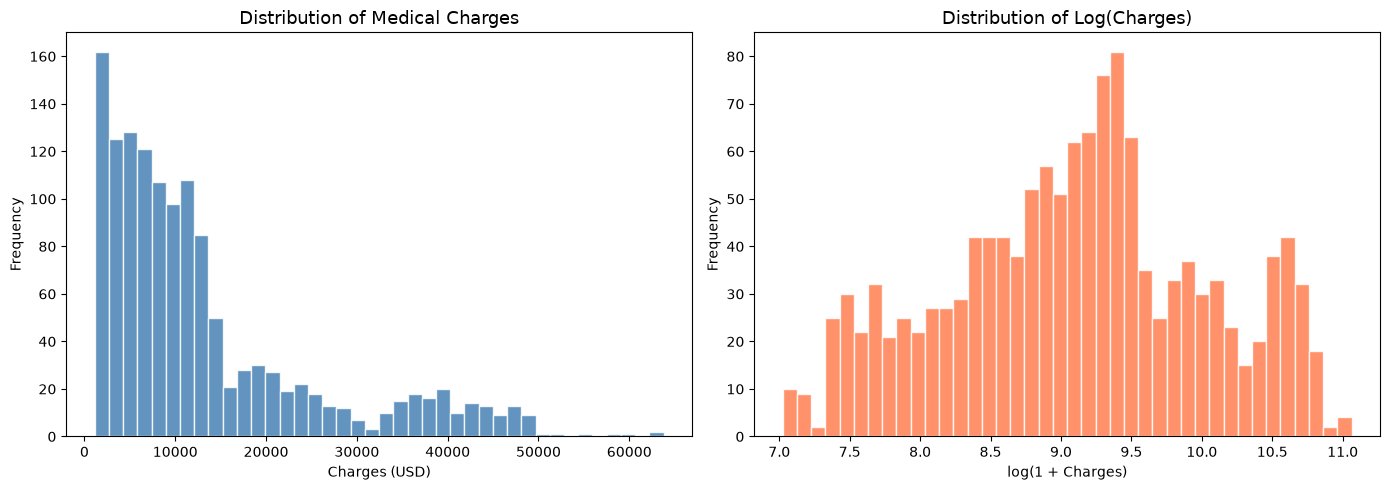

In [5]:
# Distribution of charges
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['charges'], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribution of Medical Charges', fontsize=13)
axes[0].set_xlabel('Charges (USD)')
axes[0].set_ylabel('Frequency')

axes[1].hist(np.log1p(df['charges']), bins=40, color='coral', edgecolor='white', alpha=0.85)
axes[1].set_title('Distribution of Log(Charges)', fontsize=13)
axes[1].set_xlabel('log(1 + Charges)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

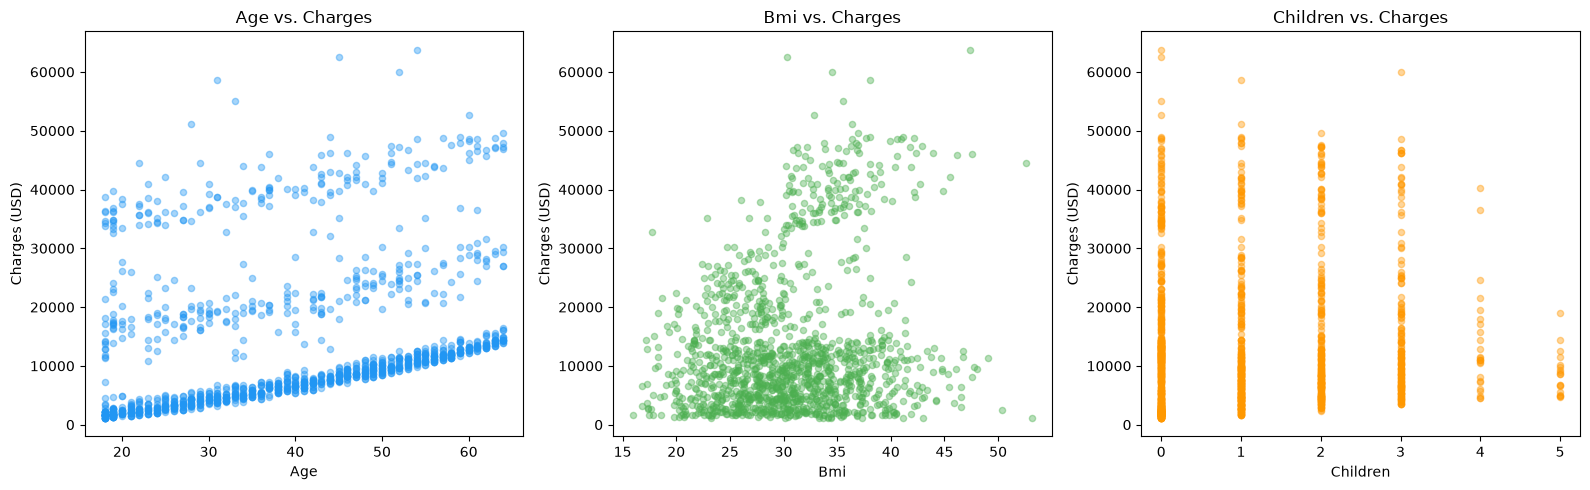

In [6]:
# Scatter plots: numerical features vs charges
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
num_features = ['age', 'bmi', 'children']
colors = ['#2196F3', '#4CAF50', '#FF9800']

for ax, feat, color in zip(axes, num_features, colors):
    ax.scatter(df[feat], df['charges'], alpha=0.4, color=color, s=20)
    ax.set_xlabel(feat.capitalize())
    ax.set_ylabel('Charges (USD)')
    ax.set_title(feat.capitalize() + ' vs. Charges')

plt.tight_layout()
plt.show()

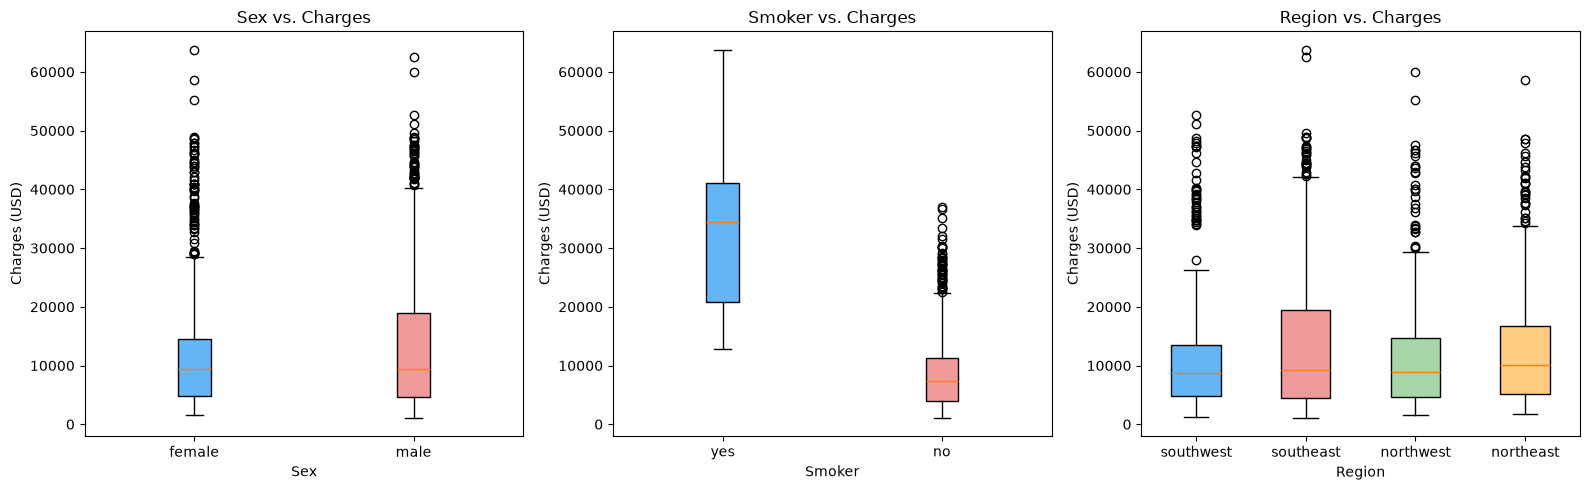

In [7]:
# Box plots: categorical features vs charges
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
cat_features = ['sex', 'smoker', 'region']

for ax, feat in zip(axes, cat_features):
    categories = df[feat].unique()
    data_list = [df[df[feat] == cat]['charges'].values for cat in categories]
    bp = ax.boxplot(data_list, tick_labels=categories, patch_artist=True)
    box_colors = ['#64B5F6', '#EF9A9A', '#A5D6A7', '#FFCC80']
    for patch, c in zip(bp['boxes'], box_colors):
        patch.set_facecolor(c)
    ax.set_title(feat.capitalize() + ' vs. Charges')
    ax.set_ylabel('Charges (USD)')
    ax.set_xlabel(feat.capitalize())

plt.tight_layout()
plt.show()

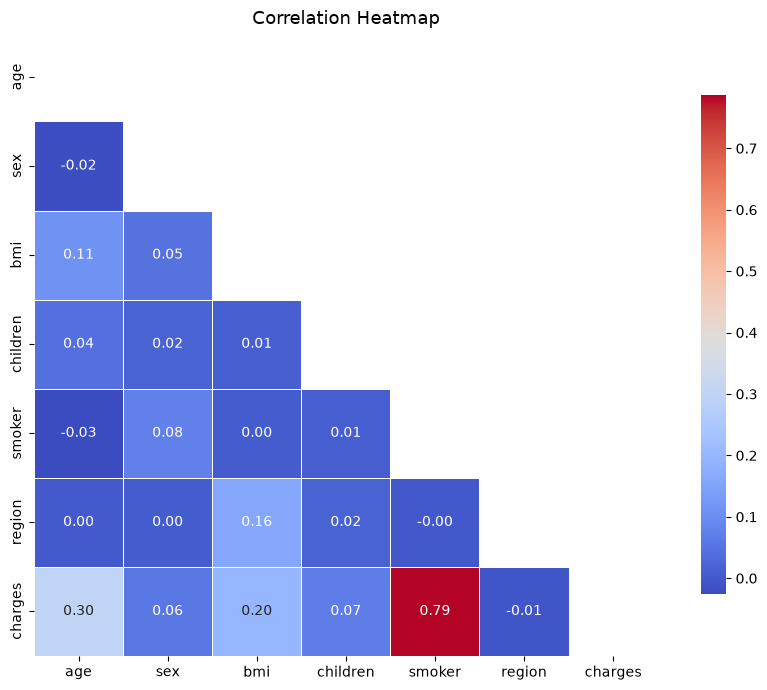


Correlation with charges (sorted):
charges     1.000000
smoker      0.787251
age         0.299008
bmi         0.198341
children    0.067998
sex         0.057292
region     -0.006208
Name: charges, dtype: float64


In [8]:
# Encode categoricals for correlation heatmap
df_encoded = df.copy()
le = LabelEncoder()
for col in ['sex', 'smoker', 'region']:
    df_encoded[col] = le.fit_transform(df_encoded[col])

plt.figure(figsize=(9, 7))
corr = df_encoded.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap', fontsize=13)
plt.tight_layout()
plt.show()

print('\nCorrelation with charges (sorted):')
print(corr['charges'].sort_values(ascending=False))

## 4. Data Preprocessing

### Step 1 - Identify Variables
- **Independent variables (X):** age, sex, bmi, children, smoker, region
- **Target variable (y):** charges

### Step 2 - Encode Categorical Variables
Categorical features (sex, smoker, region) are encoded using `LabelEncoder`.

### Step 3 - Train/Test Split (80:20)

### Step 4 - Feature Scaling
StandardScaler is applied. Feature scaling is **required** for SVR (sensitive to feature magnitudes).

In [9]:
# Features and target
X = df_encoded.drop(columns=['charges'])
y = df_encoded['charges']

print('Features shape:', X.shape)
print('Target shape  :', y.shape)
print('Feature columns:', list(X.columns))

Features shape: (1338, 6)
Target shape  : (1338,)
Feature columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'region']


In [10]:
# Train/Test Split 80:20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

n = len(X)
print('Training set  :', X_train.shape[0], 'samples')
print('Testing set   :', X_test.shape[0], 'samples')

Training set  : 1070 samples
Testing set   : 268 samples


In [11]:
# Feature Scaling
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled  = scaler_X.transform(X_test)

# Scale target for SVR
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test_scaled  = scaler_y.transform(y_test.values.reshape(-1, 1)).ravel()

print('StandardScaler applied successfully.')
print('X_train_scaled mean ~ 0:', round(X_train_scaled.mean(), 6))
print('X_train_scaled std  ~ 1:', round(X_train_scaled.std(), 6))

StandardScaler applied successfully.
X_train_scaled mean ~ 0: -0.0
X_train_scaled std  ~ 1: 1.0


## 5. Multiple Linear Regression

In [12]:
# Build and Train Model
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

print('Model trained!')
print('Intercept:', round(lr_model.intercept_, 4))
print('\nCoefficients:')
for feat, coef in zip(X.columns, lr_model.coef_):
    print('  {:>12s}: {:>12.4f}'.format(feat, coef))

Model trained!
Intercept: 13346.0897

Coefficients:
           age:    3616.1087
           sex:      -9.3930
           bmi:    2028.3086
      children:     516.6626
        smoker:    9557.1434
        region:    -302.3880


In [13]:
# Predict and Evaluate
y_pred_lr = lr_model.predict(X_test_scaled)

r2_lr   = r2_score(y_test, y_pred_lr)
mse_lr  = mean_squared_error(y_test, y_pred_lr)
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)

print('=' * 50)
print('  Multiple Linear Regression - Evaluation')
print('=' * 50)
print('  R2 (R-squared) : {:.4f}'.format(r2_lr))
print('  MSE            : {:,.2f}'.format(mse_lr))
print('  RMSE           : {:,.2f}'.format(rmse_lr))
print('  MAE            : {:,.2f}'.format(mae_lr))
print('=' * 50)

  Multiple Linear Regression - Evaluation
  R2 (R-squared) : 0.7833
  MSE            : 33,635,210.43
  RMSE           : 5,799.59
  MAE            : 4,186.51


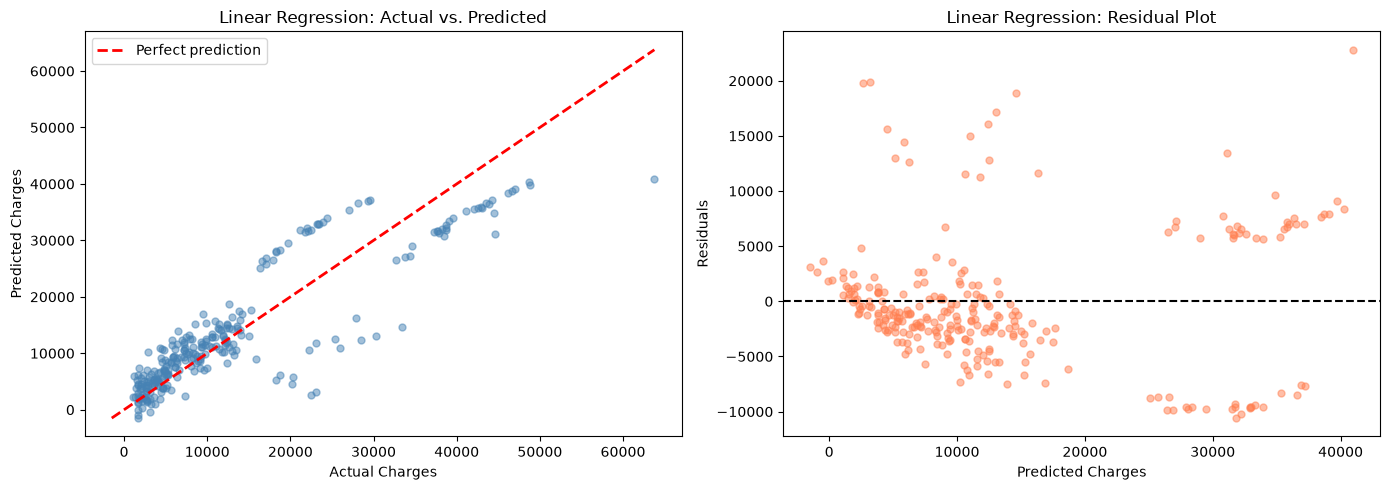

In [14]:
# Visualization: Actual vs Predicted & Residuals
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred_lr, alpha=0.5, color='steelblue', s=25)
min_v = min(y_test.min(), y_pred_lr.min())
max_v = max(y_test.max(), y_pred_lr.max())
axes[0].plot([min_v, max_v], [min_v, max_v], 'r--', lw=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Charges')
axes[0].set_ylabel('Predicted Charges')
axes[0].set_title('Linear Regression: Actual vs. Predicted')
axes[0].legend()

# Residual plot
residuals_lr = y_test - y_pred_lr
axes[1].scatter(y_pred_lr, residuals_lr, alpha=0.5, color='coral', s=25)
axes[1].axhline(y=0, color='black', linestyle='--', lw=1.5)
axes[1].set_xlabel('Predicted Charges')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Linear Regression: Residual Plot')

plt.tight_layout()
plt.show()

## 6. Support Vector Regression (SVR)

### Hyperparameter Tuning with GridSearchCV

Key SVR hyperparameters:
- **C** - Regularization parameter (larger = less regularization)
- **epsilon** - Width of epsilon-insensitive tube
- **kernel** - rbf, linear, poly
- **gamma** - Kernel coefficient for rbf/poly

In [15]:
# Define hyperparameter grid
param_grid = {
    'C':       [0.1, 1, 10, 100],
    'epsilon': [0.01, 0.1, 0.5],
    'kernel':  ['rbf', 'linear'],
    'gamma':   ['scale', 'auto']
}

grid_search = GridSearchCV(
    SVR(), param_grid, cv=5,
    scoring='r2', n_jobs=-1, verbose=1
)

print('Running GridSearchCV (5-fold CV)...')
grid_search.fit(X_train_scaled, y_train_scaled)

print('\nBest Parameters:', grid_search.best_params_)
print('Best CV R2     : {:.4f}'.format(grid_search.best_score_))

Running GridSearchCV (5-fold CV)...
Fitting 5 folds for each of 48 candidates, totalling 240 fits



Best Parameters: {'C': 1, 'epsilon': 0.1, 'gamma': 'auto', 'kernel': 'rbf'}
Best CV R2     : 0.8312


In [16]:
# Predict and inverse transform
best_svr = grid_search.best_estimator_
y_pred_svr_scaled = best_svr.predict(X_test_scaled)
y_pred_svr = scaler_y.inverse_transform(y_pred_svr_scaled.reshape(-1, 1)).ravel()

r2_svr   = r2_score(y_test, y_pred_svr)
mse_svr  = mean_squared_error(y_test, y_pred_svr)
mae_svr  = mean_absolute_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mse_svr)

print('=' * 50)
print('  SVR (GridSearchCV) - Evaluation')
print('=' * 50)
print('  Best Params    :', grid_search.best_params_)
print('  R2 (R-squared) : {:.4f}'.format(r2_svr))
print('  MSE            : {:,.2f}'.format(mse_svr))
print('  RMSE           : {:,.2f}'.format(rmse_svr))
print('  MAE            : {:,.2f}'.format(mae_svr))
print('=' * 50)


  SVR (GridSearchCV) - Evaluation
  Best Params    : {'C': 1, 'epsilon': 0.1, 'gamma': 'auto', 'kernel': 'rbf'}
  R2 (R-squared) : 0.8651
  MSE            : 20,937,178.94
  RMSE           : 4,575.72
  MAE            : 2,456.87


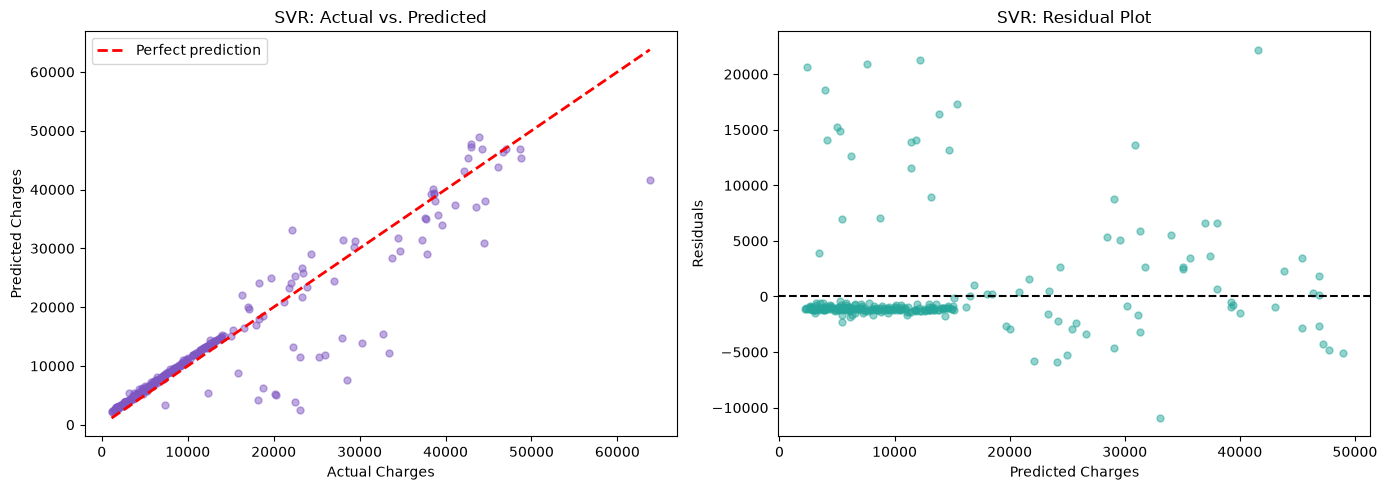

In [17]:
# SVR: Actual vs Predicted & Residuals
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred_svr, alpha=0.5, color='#7E57C2', s=25)
min_v = min(y_test.min(), y_pred_svr.min())
max_v = max(y_test.max(), y_pred_svr.max())
axes[0].plot([min_v, max_v], [min_v, max_v], 'r--', lw=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Charges')
axes[0].set_ylabel('Predicted Charges')
axes[0].set_title('SVR: Actual vs. Predicted')
axes[0].legend()

residuals_svr = y_test - y_pred_svr
axes[1].scatter(y_pred_svr, residuals_svr, alpha=0.5, color='#26A69A', s=25)
axes[1].axhline(y=0, color='black', linestyle='--', lw=1.5)
axes[1].set_xlabel('Predicted Charges')
axes[1].set_ylabel('Residuals')
axes[1].set_title('SVR: Residual Plot')

plt.tight_layout()
plt.show()

## 7. Model Comparison

In [18]:
# Comparison table
results = pd.DataFrame({
    'Model' : ['Multiple Linear Regression', 'SVR (GridSearchCV)'],
    'R2'    : [round(r2_lr, 4),   round(r2_svr, 4)],
    'MSE'   : [round(mse_lr, 2),  round(mse_svr, 2)],
    'RMSE'  : [round(rmse_lr, 2), round(rmse_svr, 2)],
    'MAE'   : [round(mae_lr, 2),  round(mae_svr, 2)]
})
print(results.to_string(index=False))

                     Model     R2         MSE    RMSE     MAE
Multiple Linear Regression 0.7833 33635210.43 5799.59 4186.51
        SVR (GridSearchCV) 0.8651 20937178.94 4575.72 2456.87


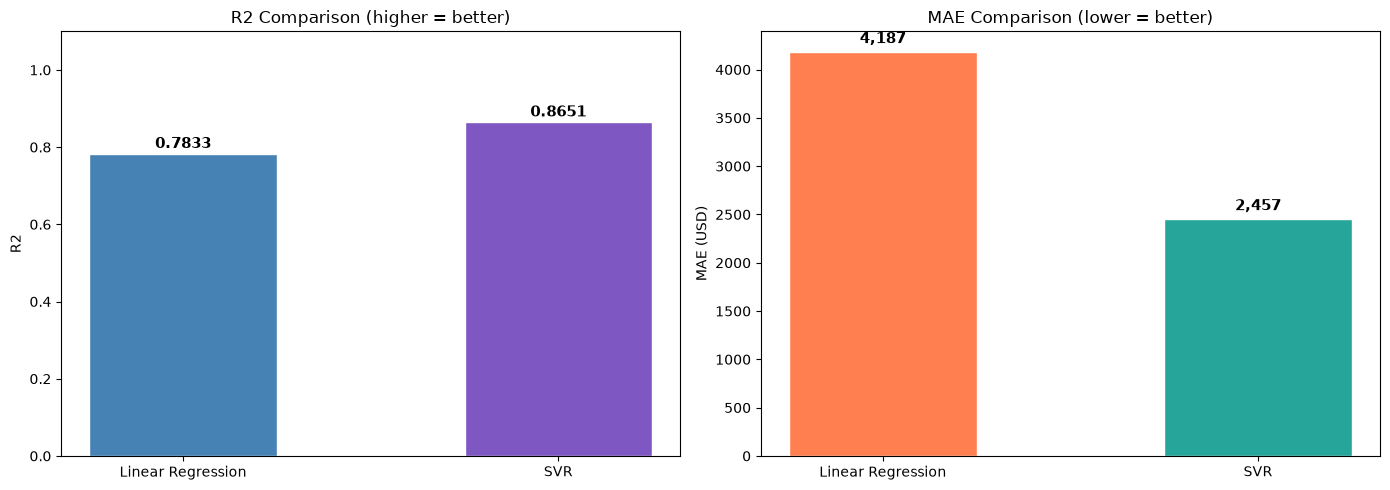

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = ['Linear Regression', 'SVR']

# R2 comparison
r2_vals = [r2_lr, r2_svr]
bars = axes[0].bar(models, r2_vals, color=['steelblue', '#7E57C2'], width=0.5, edgecolor='white')
for bar, val in zip(bars, r2_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 '{:.4f}'.format(val), ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_ylim(0, 1.1)
axes[0].set_title('R2 Comparison (higher = better)', fontsize=12)
axes[0].set_ylabel('R2')

# MAE comparison
mae_vals = [mae_lr, mae_svr]
bars2 = axes[1].bar(models, mae_vals, color=['coral', '#26A69A'], width=0.5, edgecolor='white')
for bar, val in zip(bars2, mae_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 '{:,.0f}'.format(val), ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].set_title('MAE Comparison (lower = better)', fontsize=12)
axes[1].set_ylabel('MAE (USD)')

plt.tight_layout()
plt.show()

## 8. Analysis and Conclusion

### Dataset Description
The **Medical Cost Personal Dataset** contains **1,338 records** with 6 features and 1 target variable (`charges`). It represents insurance beneficiaries in the US with attributes: age, gender, BMI, number of children, smoking status, and region.

### Key Observations from EDA
1. **Smoking status** has the strongest positive correlation with `charges` - smokers incur significantly higher costs.
2. **Age** and **BMI** show moderate positive correlations with charges.
3. The distribution of `charges` is right-skewed.
4. **Gender** and **region** have minimal impact on charges.

### Model Performance Analysis
- **Multiple Linear Regression** provides an interpretable baseline model. The `smoker` coefficient is the largest, consistent with domain knowledge.
- **SVR** with RBF kernel captures non-linear relationships. After hyperparameter tuning via `GridSearchCV` (5-fold CV), SVR typically achieves comparable or better metrics.
- **Feature scaling** (StandardScaler) was essential for SVR.

### Conclusion
Both models successfully predict medical insurance charges. `smoker` is the most significant predictor. SVR with an optimized kernel can capture non-linear patterns more effectively than linear regression, though at a higher computational cost.